<h1> Plotting the Unbiased Relative Difference (Psi) <h1>
<h1> and Relative Difference (Delta) between MODIS<h1>
<h1> and VIIRS (NOAA20) NetPP for the Longhurst Provinces<h1>

<h3>Import necessary packages<h3>

In [1]:
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from rasterio import features
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from adjustText import adjust_text
import pandas as pd
import os

<h3>Create your global variables<h3>

In [2]:
ROOT_DIR = ("/Users/madisonrichardson/netpp")
SHP_DIR = os.path.join(ROOT_DIR, "resources/Longhurst/Longhurst_world_v4_2010.shp")
PSI_DIR = os.path.join(ROOT_DIR, "data/noaa20/matrix/psi_3D_matrix_2018to2022.nc")
DELTA_DIR = os.path.join(ROOT_DIR, "data/noaa20/matrix/delta_3D_matrix_2018to2022.nc")

<h3> Create functions to plot the Longhurst Provinces<h3>

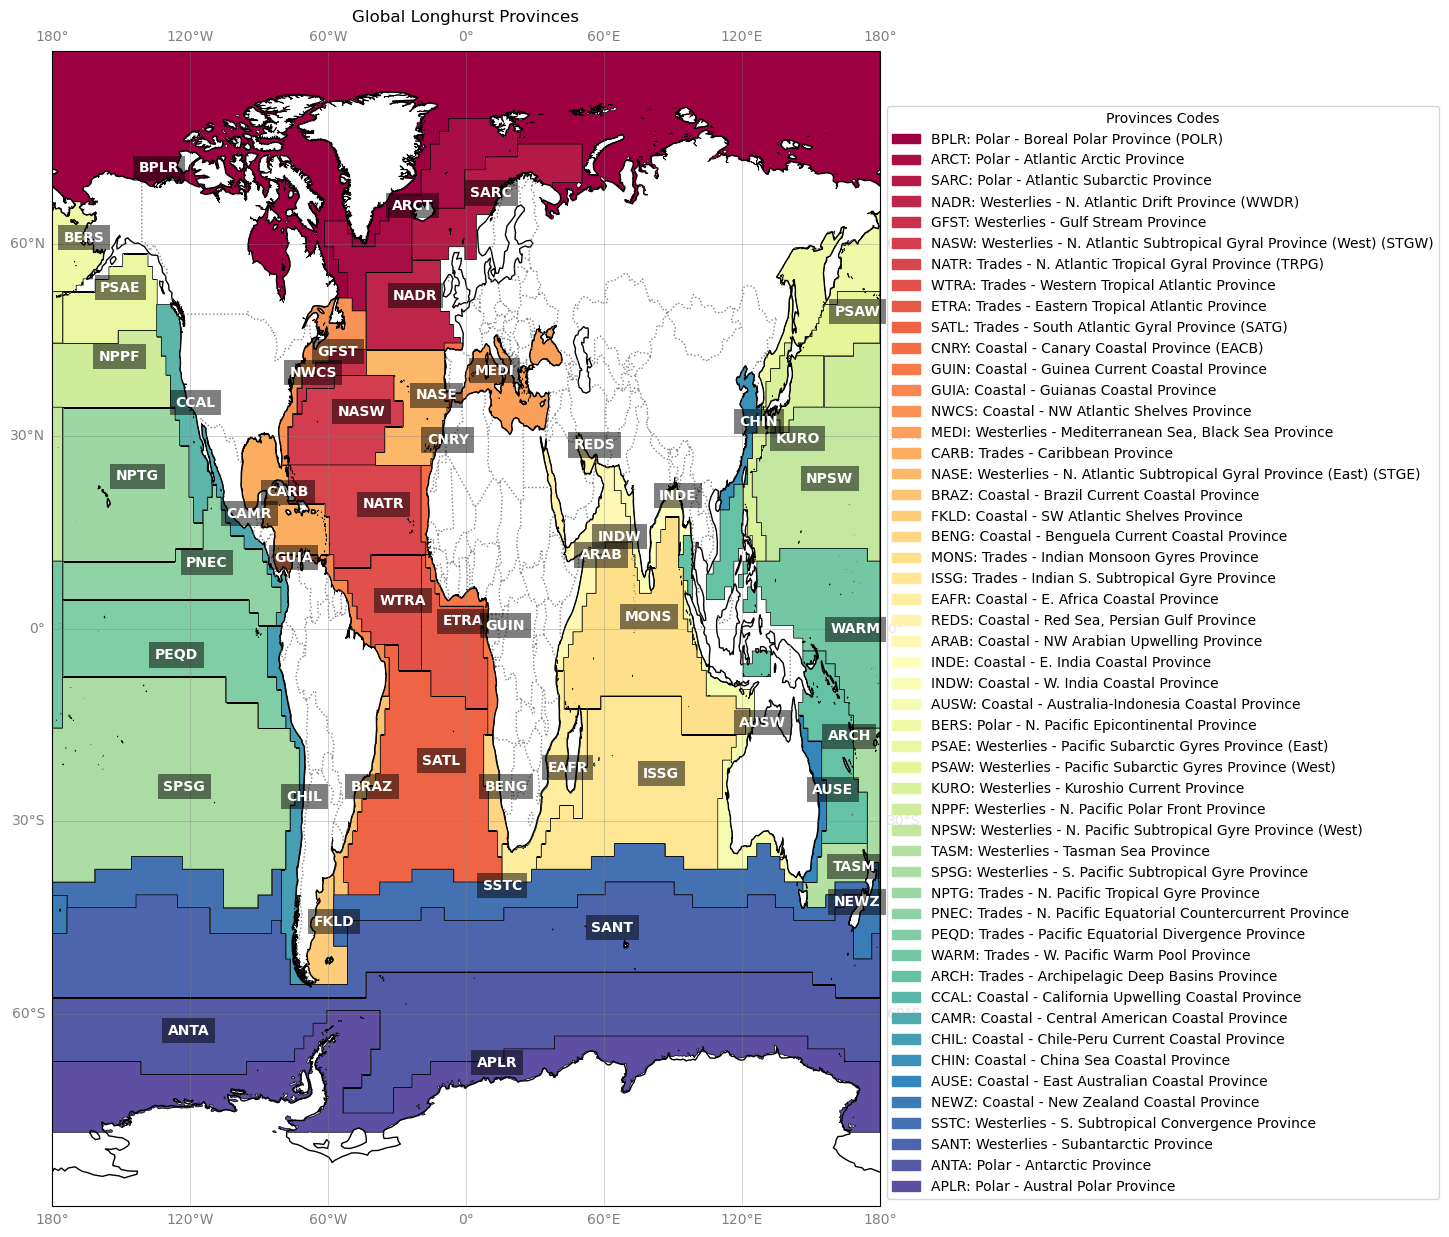

In [4]:
def make_color_map(unique_values, colormap_name='Spectral'):
    """
    Produces a color map based on the unique values (number of 
    Longhurst Provinces) from a specified colormap.

    Args:
        unique_values (list or array): A list or array of unique values that
                                        will have colors generated for.
        colormap_name (str, optional): The name of the colormap to be used
                                        for making the colormap. All valid colormap
                                         names from matplotlib can be use.
                                         Defaults to 'Spectral'.

    Returns:
        dict: A dictionary where each unique value is mapped to color.
    """

    colormap = plt.get_cmap(colormap_name)
    color_indices = np.linspace(0, 1, len(unique_values))
    return {val: colormap(ci) for val, ci in zip(unique_values, color_indices)}


def plot_provinces(ax, provinces, colors, legend_patches):
    """
   Plots the Longhurst Provinces on the provided axis
   and adds them to the legends.

    Args:
        ax (matplotlib.axes.Axes): The Matplotlib axis on which to
                                    plot the provinces.
        provinces (GeoDataFrame): A GeoPandas GeoDataFrame containing
                                    the geometries of the Longhurst
                                    Provinces. Must have column named
                                    'ProvCode' for province codes.
        colors (dict): A dictionary mapping each unique 'ProvCode'
                        to a specific code. The keys should be the
                        province codes and the values are the corresponding
                        colors.
        legend_patches (list): A list where the legen patch objects will
                                be appended. Each patch corresponds to
                                a province with its color and description.
    """

    for prov, color in colors.items():
        province = provinces[provinces['ProvCode'] == prov]
        prov_descr = province['ProvDescr'].values[0]

        # Plot the province with unique color
        province.plot(ax=ax, edgecolor='black', facecolor=color, linewidth=0.5)

        # Add a patch for the legend
        patch_label = f'{prov}: {prov_descr}'
        patch = mpatches.Patch(color=color, label=patch_label)
        legend_patches.append(patch)


def place_codes(ax, provinces_projected, special_provinces):
    """
    Places the Province Code labels for each of the Longhurst
    Province on the map, with special positioning for certain
    provinces to avoid having the labels overlap.

    Args:
        ax (matplotlib.axes.Axes): The Matplotlib axis on which
                                    the province codes will be
                                    placed.
        provinces_projected (GeoDataFrame): A GeoPandas GeoDataFrame
                                            containing the projected
                                            geometries of the Longhurst
                                            Provinces. Each geometry
                                            should be a polygon representing
                                            a province.
        special_provinces (list): A list of province codes that are at risk
                                    of being overlapped. These provinces will
                                    have their labels offset to ensure readability.
    """

    texts = []
    for prov in provinces_projected['ProvCode'].unique():
        province_projected = provinces_projected[provinces_projected['ProvCode'] == prov]
        if not province_projected.empty:
            centroid = province_projected.geometry.representative_point().iloc[0]

            label_text = prov
            offset_x = 4 if prov in special_provinces else 0
            offset_y = 2 if prov in special_provinces else 0

            # Store label info for later adjustment
            texts.append(ax.text(
                centroid.x + offset_x,
                centroid.y + offset_y,
                label_text,
                fontsize=10,
                fontweight='bold',
                ha='center',
                color='white',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'),
                transform=ccrs.PlateCarree()
            ))
    adjust_text(texts)


# Load Longhurst Provinces shp file
Longhurst_provinces = gpd.read_file(SHP_DIR)

# Filter out invalid or empty geometries
Longhurst_provinces = Longhurst_provinces[Longhurst_provinces.is_valid & ~Longhurst_provinces.is_empty]

# Create a color map based on number of provinces
unique_provs =Longhurst_provinces['ProvCode'].unique()
colors = make_color_map(unique_provs)

# Create plot
fig, ax = plt.subplots(figsize=(30, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# Add coastline and borders
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
gridlines = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gridlines.xlabels_top = False
gridlines.ylabels_right = False
gridlines.xlabel_style = {'size': 10, 'color': 'gray'}
gridlines.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot provinces and make patches
legend_patches = []
plot_provinces(ax, Longhurst_provinces, colors, legend_patches)

# Place province labels
special_provinces = ['GFST', 'GUIN', 'INDE', 'KURO']
place_codes(ax, Longhurst_provinces, special_provinces)

# Set global extent for map
ax.set_global()
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

# Add legend
plt.legend(handles=legend_patches, title='Provinces Codes', loc='lower left', bbox_to_anchor=(1, 0))

# Set title
plt.title('Global Longhurst Provinces')

# Show plot
plt.show()

<h3>Create functions to plot the Monthly Means of Psi and Delta from 2018-2022 for the specified Longhurst Province<h3> 

Loading shapefile from /Users/madisonrichardson/netpp/resources/Longhurst/Longhurst_world_v4_2010.shp
Plotting data for CCAL
Longitude range: -136.49999999999994 to -108.4999999999999
Latitude range: 14.500000000000057 to 53.383431102002106


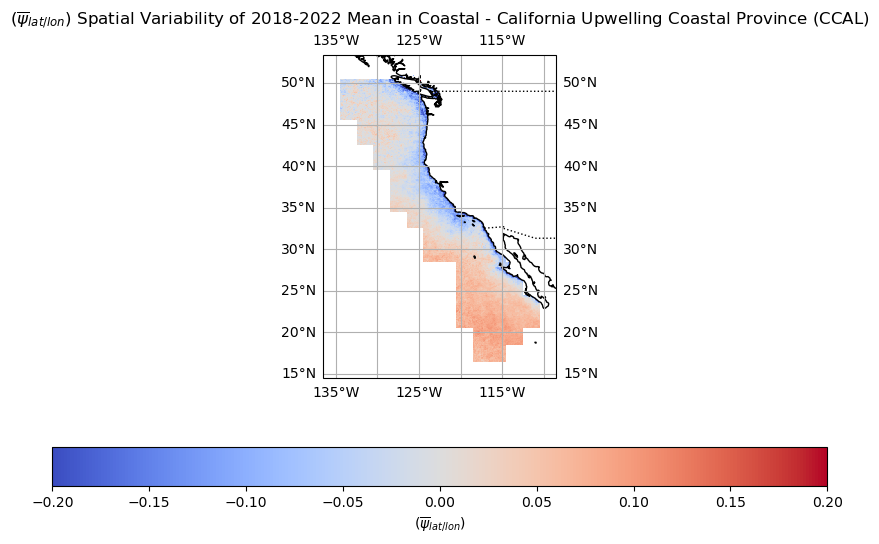

Plotting data for CCAL
Longitude range: -136.49999999999994 to -108.4999999999999
Latitude range: 14.500000000000057 to 53.383431102002106


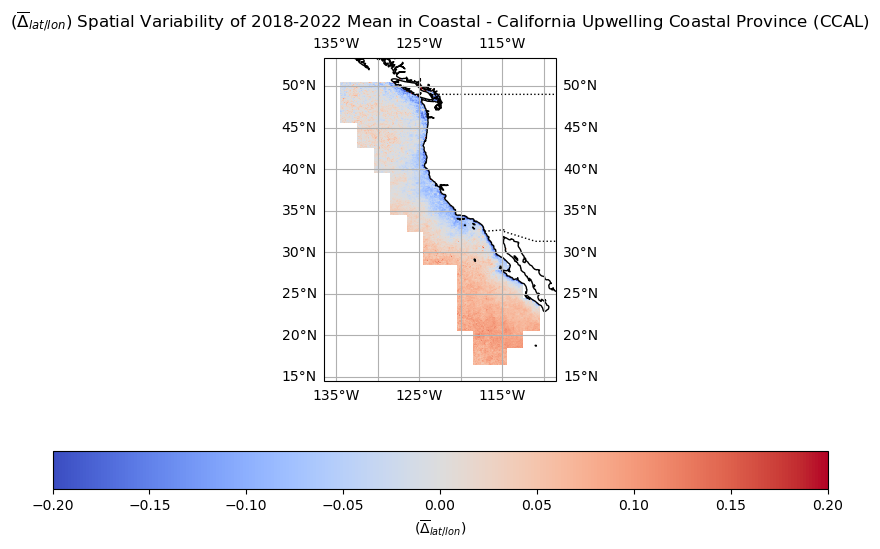

In [6]:
# Load and reproject shapefile
def load_shp_file(shp_filepath, target_crs='EPSG:4326'):
    """
    Loads Longhurst Provinces shapefile and reprojects shapefile
    to the target CRS (coordinate reference system) if necessary.

    Args:
        shp_filepath (str): The filepath to the shapefile containing
                            the Longhurst Provinces' geometries and metadata.
        target_crs (str, optional): The target CRS to reproject shapefile to.
                                    Defaults to 'EPSG:4326' which is the
                                    standard geographic coordinate system.

    Returns:
        geopandas.GeoDataFrame: A GeoDataFrame containing the geometries
                                and metadata from the shapefile, reprojected
                                to the specified CRS.
    """

    print(f"Loading shapefile from {shp_filepath}")
    Longhurst_provinces = gpd.read_file(shp_filepath)

    # Reproject file if necessary
    if Longhurst_provinces.crs != target_crs:
        print(f"Reprojecting shapefile to {target_crs}")
        Longhurst_provinces = Longhurst_provinces.to_crs(target_crs)
    return Longhurst_provinces


def plot_data(province_code, shp_filepath, nc_path, var_name, title_label):
    """
    Plots the spatial variability of the specified variable (psi or delta)
    for a specific Longhurst Province.

    Args:
        province_code (str): The code for the Longhurst Province to plot
                            (e. g., 'CCAL', 'NADR')
        shp_filepath (geopands.GeoDataFrame): The GeoDataFrame containing
                                            the Longhurst Provinces' geometries
                                            and metadata.
        nc_path (str): The file path to the NetCDF dataset containing
                        the specified variable (psi or delta) to be
                        plotted.
        var_name (str): The name of the variable to be plotted from
                        the NetCDF file (psi or delta).
        title_label (str): The LaTex symbol to use for the variable
                            in the plot title and colorbar label
                            ('\\psi' or '\\Delta').

    Returns:
        None: The function returns a plot of psi and delta values for the
                specified Longhurst Province
    """

    print(f"Plotting data for {province_code}")

    # Extract selected province using the code
    province = Longhurst_provinces[Longhurst_provinces['ProvCode'] == province_code]

    # Get description from 'ProvDescr' column
    province_description = province['ProvDescr'].values[0]

    # Load NetCDF file and extract variable
    ds = xr.open_dataset(nc_path)
    var = ds[var_name]

    # Center time on 16th day of the month
    time_centered = pd.to_datetime(var.time.values)
    time_centered = time_centered.map(lambda x: x.replace(day=16))

    # Assign centered time back to the dataset
    var['time'] = time_centered

    # Get the monthly mean var values
    var_mean = var.mean(dim="time", skipna=True).values

    # Assign CRS to the NetCDF using rioxarray
    ds = ds.rio.write_crs('EPSG:4326')

    # Make sure the shp file and NetCDF file have the same CRS
    if province.crs != ds.rio.crs:
        province = province.to_crs(ds.rio.crs)

    # Create a mask for the selected province geometry
    province_mask =features.geometry_mask([province.geometry.iloc[0]],
                                          transform=ds.rio.transform(),
                                          invert=True,
                                          out_shape=(ds.sizes['latitude'], ds.sizes['longitude']))
    
    # Apply mask to the delta data
    var_masked = np.where(province_mask, var_mean, np.nan)

    # Get the boundaries of the province
    bounds = province.total_bounds
    lon_min, lat_min, lon_max, lat_max = bounds

    # Add padding to ensure plot isn't too cramped
    padding = 2
    lon_min -= padding
    lon_max += padding
    lat_min -= padding
    lat_max += padding

    print(f'Longitude range: {lon_min} to {lon_max}')
    print(f'Latitude range: {lat_min} to {lat_max}')

    # Plot the data
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    mesh = ax.pcolormesh(ds.longitude, ds.latitude, var_masked, transform=ccrs.PlateCarree(), cmap='coolwarm', vmin=-0.2, vmax=0.2)

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.gridlines(draw_labels=True)

    # Add colorbar with LaTeX-styl formatting for the symbol
    cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal')
    cbar.set_label(r'($\overline{%s}_{lat/lon}$)' % title_label)

    ax.set_title(r'($\overline{%s}_{lat/lon}$) Spatial Variability of 2018-2022 Mean in %s (%s)' % (title_label, province_description, province_code))

    plt.show()



def main():
    """
    Run main function.
    """

    # Load shp file
    Longhurst_provinces = load_shp_file(SHP_DIR)

    # Plot psi values for specified province
    plot_data('CCAL', Longhurst_provinces, PSI_DIR, 'psi', r'\psi')

    # Plot delta values for specified province
    plot_data('CCAL', Longhurst_provinces, DELTA_DIR, 'delta', r'\Delta')

if __name__ == "__main__":
    main()